
# Variabilidade e convergência de gerações Gherkin com Normalized Token-Level Levenshtein Distance

Este notebook recebe **um JSON de gerações** no formato:

- `model`
- `technique`
- `number_of_executions`
- `cases[]`
  - `case_id`
  - `original_case`
  - `generations[]`
    - `execution`
    - `gherkin`

## Objetivo

A análise mede **variação textual entre diferentes execuções do mesmo caso-base**.

Não há comparação entre casos diferentes e não há comparação com uma referência. Para cada `case_id`, as diferentes gerações são comparadas **par a par**.

## Métrica

Cada texto Gherkin é convertido em uma sequência de tokens:

\[
T(G) = [t_1,t_2,\ldots,t_k]
\]

A distância de Levenshtein em nível de tokens corresponde ao número mínimo de:

- inserções de tokens;
- remoções de tokens;
- substituições de tokens;

necessárias para transformar uma sequência na outra.

A distância normalizada usada neste notebook é:

\[
D_{NTL}(A,B)=
\frac{Lev(T(A),T(B))}
{\max(|T(A)|,|T(B)|)}
\]

com:

\[
0 \le D_{NTL}(A,B) \le 1
\]

Interpretação:

- `0` → sequências de tokens idênticas após a normalização textual configurada;
- valores próximos de `0` → pouca variação textual;
- valores maiores → maior variação textual;
- `1` → distância de edição máxima para aquele par segundo esta normalização.

> A métrica mede **variação textual**, não equivalência semântica. Sinônimos diferentes continuam sendo tokens diferentes.

## Variabilidade por caso

Para um caso \(c\), considerando as primeiras \(n\) execuções:

\[
V_c(n)=
\frac{1}{\binom{n}{2}}
\sum_{i<j}
D_{NTL}(G_{c,i},G_{c,j})
\]

## Variabilidade global da configuração

Se existem \(C\) casos-base:

\[
V(n)=
\frac{1}{C}
\sum_{c=1}^{C}V_c(n)
\]

Assim, **cada caso-base recebe o mesmo peso** na estimativa global.

## Convergência

Como a métrica está em uma escala fixa \([0,1]\), o notebook usa **tolerância absoluta**.

Se \(N\) é o número total de execuções disponíveis:

\[
V_{final}=V(N)
\]

O ponto de convergência é o menor \(n\) para o qual:

\[
|V(m)-V(N)| \le \epsilon
\quad \forall m \ge n
\]

Além disso, o notebook exige um número mínimo de execuções posteriores ao candidato, evitando considerar a própria última execução como uma convergência trivial.

Por padrão:

- `MIN_N_CONVERGENCIA = 10`;
- `TOLERANCIA_ABSOLUTA = 0.01`;
- `MIN_EXECUCOES_POSTERIORES = 5`.

Portanto, com 20 execuções, um ponto em `n = 15` ainda pode ser confirmado porque existem 5 execuções posteriores (`16...20`). Um ponto em `n = 18`, por exemplo, será considerado **não confirmado com N=20**, pois ainda faltam observações posteriores suficientes.


In [ ]:

# Instalação das dependências
# RapidFuzz implementa Levenshtein de forma eficiente.

%pip install -q rapidfuzz pandas numpy matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 25.5 MB/s eta 0:00:00


In [ ]:

# =========================
# CONFIGURAÇÃO DA ANÁLISE
# =========================

# Colab: deixe None para abrir o seletor de upload.
# Jupyter/local: informe o caminho do JSON.
ARQUIVO_JSON = None

# -------------------------
# Normalização/tokenização
# -------------------------

# Ignora diferenças apenas de maiúsculas/minúsculas.
CONVERTER_PARA_MINUSCULAS = True

# Mantém pontuação como tokens separados.
# Ex.: ":" e aspas também podem contribuir para a distância textual.
CONSIDERAR_PONTUACAO = True

# -------------------------
# Critério de convergência
# -------------------------

MIN_N_CONVERGENCIA = 10

# Como a métrica varia de 0 a 1, usamos diferença ABSOLUTA.
# Ex.: 0.01 significa que V(n) deve permanecer a no máximo
# 0.01 unidade da estimativa obtida com todas as execuções.
#
# Este é um critério operacional de precisão do estudo,
# não um limiar universal.
TOLERANCIA_ABSOLUTA = 0.01

# Evita declarar convergência apenas porque chegamos ao último ponto.
# O candidato precisa ter pelo menos esta quantidade de execuções posteriores.
MIN_EXECUCOES_POSTERIORES = 5

# -------------------------
# IC bootstrap sobre CASOS
# -------------------------

CALCULAR_BOOTSTRAP = True
N_BOOTSTRAP = 1000
SEED_BOOTSTRAP = 2026

# Quantidade de casos exibidos nos rankings/gráficos.
TOP_CASOS = 20

# Análise de sensibilidade opcional para a tolerância.
TOLERANCIAS_SENSIBILIDADE = [0.005, 0.01, 0.02]


In [ ]:

import json
import math
import re
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rapidfuzz.distance import Levenshtein

pd.set_option("display.max_colwidth", 120)


In [ ]:

# =========================
# ENTRADA DO JSON
# =========================

if ARQUIVO_JSON is None:
    try:
        from google.colab import files
        uploaded = files.upload()

        if not uploaded:
            raise ValueError("Nenhum arquivo foi enviado.")

        ARQUIVO_JSON = next(iter(uploaded.keys()))

    except ImportError:
        raise ValueError(
            "Fora do Google Colab, defina ARQUIVO_JSON com o caminho do arquivo JSON."
        )

with open(ARQUIVO_JSON, "r", encoding="utf-8") as f:
    dados = json.load(f)

campos_obrigatorios = {
    "model",
    "technique",
    "number_of_executions",
    "cases"
}

faltantes = campos_obrigatorios - set(dados.keys())

if faltantes:
    raise ValueError(
        f"Campos obrigatórios ausentes no JSON: {sorted(faltantes)}"
    )

modelo_llm = dados["model"]
tecnica = dados["technique"]
n_declarado = int(dados["number_of_executions"])
casos = dados["cases"]

print("Arquivo:", ARQUIVO_JSON)
print("Modelo LLM:", modelo_llm)
print("Técnica:", tecnica)
print("Casos:", len(casos))
print("Execuções declaradas:", n_declarado)


Saving geracoes_gherkin_meta-llama-meta-llama-3-8b-instruct_one-shot.json to geracoes_gherkin_meta-llama-meta-llama-3-8b-instruct_one-shot.json
Arquivo: geracoes_gherkin_meta-llama-meta-llama-3-8b-instruct_one-shot.json
Modelo LLM: meta-llama/Meta-Llama-3-8B-Instruct
Técnica: one-shot
Casos: 259
Execuções declaradas: 10


In [ ]:

# =========================
# VALIDAÇÃO DA ESTRUTURA
# =========================

registros = []
problemas = []

for caso in casos:

    case_id = caso.get("case_id")
    original_case = caso.get("original_case", "")
    geracoes = caso.get("generations", [])

    execucoes = sorted(
        [
            g for g in geracoes
            if isinstance(g.get("gherkin"), str)
            and g.get("gherkin").strip()
        ],
        key=lambda x: int(x["execution"])
    )

    ids_execucao = [
        int(g["execution"])
        for g in execucoes
    ]

    if len(execucoes) != n_declarado:
        problemas.append(
            f"{case_id}: {len(execucoes)} gerações válidas; "
            f"esperado {n_declarado}."
        )

    if ids_execucao != list(
        range(1, len(execucoes) + 1)
    ):
        problemas.append(
            f"{case_id}: numeração das execuções não é sequencial: "
            f"{ids_execucao[:10]}..."
        )

    for g in execucoes:

        registros.append({
            "case_id": case_id,
            "original_case": original_case,
            "execution": int(g["execution"]),
            "generation_id": g.get("generation_id"),
            "gherkin": g["gherkin"].strip()
        })

if problemas:

    print("Problemas encontrados:")

    for p in problemas[:20]:
        print("-", p)

    raise ValueError(
        "O arquivo possui casos incompletos ou numeração inconsistente. "
        "Corrija o JSON antes da análise."
    )

df = pd.DataFrame(registros)

contagens = (
    df.groupby("case_id")["execution"]
    .nunique()
)

if contagens.nunique() != 1:
    raise ValueError(
        "Os casos não possuem a mesma quantidade de execuções."
    )

N_MAX = int(contagens.iloc[0])

if N_MAX != n_declarado:
    raise ValueError(
        f"O JSON declara {n_declarado} execuções, "
        f"mas foram encontradas {N_MAX} por caso."
    )

print(
    f"Estrutura válida: "
    f"{df['case_id'].nunique()} casos × {N_MAX} execuções."
)

display(df.head())


Estrutura válida: 259 casos × 10 execuções.


,case_id,original_case,execution,generation_id,gherkin
0,TC_261,Cancel editing project variable,1,TC_261__meta-llama-meta-llama-3-8b-instruct__one-shot__exec-01,Scenario: Cancelar edição de variável do projeto\n Given o usuário está editando uma variável do projeto\n When o ...
1,TC_261,Cancel editing project variable,2,TC_261__meta-llama-meta-llama-3-8b-instruct__one-shot__exec-02,Scenario: Cancelar edição de variável de projeto\n Given o usuário está editando uma variável de projeto\n When o ...
2,TC_261,Cancel editing project variable,3,TC_261__meta-llama-meta-llama-3-8b-instruct__one-shot__exec-03,Scenario: Cancelar edição de variável de projeto\n Given o projeto está sendo editado\n When o usuário cancela a e...
3,TC_261,Cancel editing project variable,4,TC_261__meta-llama-meta-llama-3-8b-instruct__one-shot__exec-04,Scenario: Cancelar edição de variável do projeto\n Given o usuário está editando uma variável do projeto\n When o ...
4,TC_261,Cancel editing project variable,5,TC_261__meta-llama-meta-llama-3-8b-instruct__one-shot__exec-05,Scenario: Cancelar edição de variável do projeto\n Given o usuário está editando uma variável do projeto\n When o ...



## Tokenização utilizada

A análise não usa embeddings.

Antes do cálculo de Levenshtein, o notebook aplica apenas uma normalização mínima:

1. normalização Unicode `NFKC`;
2. conversão opcional para minúsculas;
3. separação em tokens;
4. espaços e quebras de linha não contam como tokens;
5. pontuação pode ser mantida como token, conforme a configuração.

Não são aplicados:

- stemming;
- lematização;
- remoção de stopwords;
- substituição de sinônimos;
- tradução;
- embeddings.

Isso é intencional: o objetivo desta métrica é quantificar **variação textual observável entre as gerações**.


In [ ]:

# =========================
# TOKENIZAÇÃO E LEVENSHTEIN
# =========================

def tokenizar(texto):
    texto = unicodedata.normalize("NFKC", str(texto))

    if CONVERTER_PARA_MINUSCULAS:
        texto = texto.lower()

    if CONSIDERAR_PONTUACAO:
        # Palavras Unicode + pontuação como tokens separados.
        tokens = re.findall(
            r"\w+(?:['’]\w+)?|[^\w\s]",
            texto,
            flags=re.UNICODE
        )
    else:
        # Apenas palavras.
        tokens = re.findall(
            r"\w+(?:['’]\w+)?",
            texto,
            flags=re.UNICODE
        )

    return tokens


def distancia_levenshtein_tokens_normalizada(tokens_a, tokens_b):
    tamanho_max = max(
        len(tokens_a),
        len(tokens_b)
    )

    if tamanho_max == 0:
        return 0.0

    distancia = Levenshtein.distance(
        tokens_a,
        tokens_b
    )

    return float(
        distancia / tamanho_max
    )


# Pequenos testes de sanidade da implementação.
assert distancia_levenshtein_tokens_normalizada(
    ["given", "a"],
    ["given", "a"]
) == 0.0

assert np.isclose(
    distancia_levenshtein_tokens_normalizada(
        ["given", "a"],
        ["given", "b"]
    ),
    0.5
)

assert distancia_levenshtein_tokens_normalizada(
    [],
    ["given"]
) == 1.0

df["tokens"] = df["gherkin"].apply(tokenizar)
df["n_tokens"] = df["tokens"].apply(len)

print("Exemplo de tokenização:")
print(df.iloc[0]["tokens"])
print()
print("Quantidade de tokens:", df.iloc[0]["n_tokens"])


Exemplo de tokenização:
['scenario', ':', 'cancelar', 'edição', 'de', 'variável', 'do', 'projeto', 'given', 'o', 'usuário', 'está', 'editando', 'uma', 'variável', 'do', 'projeto', 'when', 'o', 'usuário', 'decide', 'cancelar', 'a', 'edição', 'da', 'variável', 'then', 'a', 'edição', 'da', 'variável', 'é', 'cancelada', 'and', 'a', 'variável', 'permanece', 'intacta']

Quantidade de tokens: 38


In [ ]:

# =========================
# MATRIZES DE DISTÂNCIA
# NORMALIZED TOKEN-LEVEL LEVENSHTEIN
# =========================

matrizes_distancia = {}
metadados_casos = {}

for case_id, grupo in df.groupby(
    "case_id",
    sort=False
):

    grupo = grupo.sort_values(
        "execution"
    )

    sequencias = grupo["tokens"].tolist()
    N = len(sequencias)

    matriz = np.zeros(
        (N, N),
        dtype=float
    )

    for i in range(N):
        for j in range(i + 1, N):

            d = distancia_levenshtein_tokens_normalizada(
                sequencias[i],
                sequencias[j]
            )

            matriz[i, j] = d
            matriz[j, i] = d

    matrizes_distancia[case_id] = matriz

    metadados_casos[case_id] = {
        "original_case":
            grupo["original_case"].iloc[0]
    }

print(
    "Matrizes calculadas:",
    len(matrizes_distancia)
)

print(
    "Dimensão de cada matriz:",
    next(
        iter(
            matrizes_distancia.values()
        )
    ).shape
)

print(
    "Faixa observada:",
    min(m.min() for m in matrizes_distancia.values()),
    "a",
    max(m.max() for m in matrizes_distancia.values())
)


Matrizes calculadas: 259
Dimensão de cada matriz: (10, 10)
Faixa observada: 0.0 a 0.8181818181818182


In [ ]:

# =========================
# FUNÇÕES DE VARIABILIDADE
# =========================

def variabilidade_cumulativa_matriz(matriz):
    # Retorna V_c(n) para n = 2...N.
    #
    # Ao adicionar a execução n, entram apenas
    # as distâncias entre a nova execução
    # e as n-1 anteriores.

    N = matriz.shape[0]

    resultados = {}
    soma_pares = 0.0

    for n in range(2, N + 1):

        novo_indice = n - 1

        soma_pares += float(
            matriz[
                novo_indice,
                :novo_indice
            ].sum()
        )

        quantidade_pares = math.comb(
            n,
            2
        )

        resultados[n] = (
            soma_pares
            / quantidade_pares
        )

    return resultados


def bootstrap_media(
    valores,
    n_bootstrap=1000,
    seed=2026,
    confidence=0.95
):
    # Bootstrap sobre os CASOS,
    # e não sobre os pares de cada caso.

    valores = np.asarray(
        valores,
        dtype=float
    )

    rng = np.random.default_rng(
        seed
    )

    amostras = rng.choice(
        valores,
        size=(
            n_bootstrap,
            len(valores)
        ),
        replace=True
    )

    medias = amostras.mean(
        axis=1
    )

    alpha = 1 - confidence

    return (
        float(
            np.quantile(
                medias,
                alpha / 2
            )
        ),
        float(
            np.quantile(
                medias,
                1 - alpha / 2
            )
        )
    )


In [ ]:

# =========================
# CURVA GLOBAL DE VARIABILIDADE
# =========================

variabilidade_por_caso_n = {}

for case_id, matriz in matrizes_distancia.items():

    variabilidade_por_caso_n[
        case_id
    ] = (
        variabilidade_cumulativa_matriz(
            matriz
        )
    )

linhas_curva = []

for n in range(
    2,
    N_MAX + 1
):

    valores = np.array(
        [
            variabilidade_por_caso_n[c][n]
            for c
            in variabilidade_por_caso_n
        ],
        dtype=float
    )

    linha = {
        "n_execucoes": n,
        "n_pares_por_caso":
            math.comb(n, 2),

        "media_variabilidade_levenshtein":
            float(valores.mean()),

        "mediana_variabilidade_levenshtein":
            float(np.median(valores)),

        "desvio_padrao_entre_casos":
            float(valores.std(ddof=1)),

        "q1":
            float(
                np.quantile(
                    valores,
                    0.25
                )
            ),

        "q3":
            float(
                np.quantile(
                    valores,
                    0.75
                )
            ),

        "iqr":
            float(
                np.quantile(
                    valores,
                    0.75
                )
                -
                np.quantile(
                    valores,
                    0.25
                )
            ),

        "min":
            float(valores.min()),

        "max":
            float(valores.max())
    }

    if CALCULAR_BOOTSTRAP:

        ic_inf, ic_sup = bootstrap_media(
            valores,
            n_bootstrap=N_BOOTSTRAP,
            seed=SEED_BOOTSTRAP + n
        )

        linha[
            "ic95_bootstrap_inferior"
        ] = ic_inf

        linha[
            "ic95_bootstrap_superior"
        ] = ic_sup

        linha[
            "largura_ic95_bootstrap"
        ] = (
            ic_sup - ic_inf
        )

    linhas_curva.append(
        linha
    )

curva = pd.DataFrame(
    linhas_curva
)

display(curva)


,n_execucoes,n_pares_por_caso,media_variabilidade_levenshtein,mediana_variabilidade_levenshtein,desvio_padrao_entre_casos,q1,q3,iqr,min,max,ic95_bootstrap_inferior,ic95_bootstrap_superior,largura_ic95_bootstrap
0,2,1,0.320368,0.317073,0.183942,0.180195,0.448628,0.268433,0.0,0.785714,0.298607,0.343937,0.045329
1,3,3,0.321854,0.328162,0.147634,0.229322,0.426259,0.196936,0.0,0.687179,0.304307,0.339859,0.035551
2,4,6,0.317665,0.317650,0.130259,0.230824,0.424044,0.193220,0.0,0.606410,0.301232,0.333881,0.032649
3,5,10,0.314396,0.320610,0.125596,0.220448,0.409621,0.189173,0.0,0.614564,0.298849,0.329300,0.030452
4,6,15,0.312958,0.322880,0.124046,0.228917,0.402850,0.173933,0.0,0.605233,0.297961,0.328586,0.030625
5,7,21,0.314627,0.319673,0.120438,0.234169,0.398466,0.164297,0.0,0.586799,0.299925,0.328819,0.028894
6,8,28,0.313654,0.316154,0.118491,0.234886,0.407217,0.172331,0.0,0.580967,0.299178,0.327209,0.028032
7,9,36,0.312593,0.311270,0.117439,0.233135,0.398390,0.165255,0.0,0.587312,0.298277,0.325498,0.027220
8,10,45,0.313572,0.316940,0.117334,0.235283,0.396811,0.161528,0.0,0.595646,0.299769,0.328111,0.028342



## Critério de convergência estável

O valor de referência é:

\[
V_{final}=V(N)
\]

Para cada \(n\), calcula-se:

\[
ErroAbs(n)=|V(n)-V(N)|
\]

Com `TOLERANCIA_ABSOLUTA = 0.01`, uma estimativa está dentro da faixa quando:

\[
ErroAbs(n)\le 0.01
\]

Entretanto, isso ainda não é suficiente para declarar convergência.

O notebook exige que:

1. o candidato seja pelo menos `MIN_N_CONVERGENCIA`;
2. ele esteja dentro da tolerância;
3. **todos os pontos posteriores até N também permaneçam dentro da tolerância**;
4. existam pelo menos `MIN_EXECUCOES_POSTERIORES` após o candidato.

A quarta condição evita o resultado trivial de declarar a última execução como ponto de convergência.


In [ ]:

# =========================
# CONVERGÊNCIA RETROSPECTIVA ESTÁVEL
# =========================

COLUNA_VARIABILIDADE = (
    "media_variabilidade_levenshtein"
)

V_FINAL = float(
    curva.loc[
        curva["n_execucoes"] == N_MAX,
        COLUNA_VARIABILIDADE
    ].iloc[0]
)

curva[
    "erro_absoluto_ao_final"
] = np.abs(
    curva[
        COLUNA_VARIABILIDADE
    ]
    - V_FINAL
)

curva[
    "dentro_tolerancia"
] = (
    curva[
        "erro_absoluto_ao_final"
    ]
    <= TOLERANCIA_ABSOLUTA
)

# Verifica, de trás para frente,
# se este ponto e TODOS os posteriores
# permanecem dentro da tolerância.

flags = (
    curva[
        "dentro_tolerancia"
    ]
    .to_numpy()
)

estavel_daqui_em_diante = np.zeros(
    len(flags),
    dtype=bool
)

acumulado = True

for i in range(
    len(flags) - 1,
    -1,
    -1
):

    acumulado = (
        acumulado
        and bool(flags[i])
    )

    estavel_daqui_em_diante[i] = (
        acumulado
    )

curva[
    "estavel_daqui_em_diante"
] = estavel_daqui_em_diante

curva[
    "execucoes_posteriores_disponiveis"
] = (
    N_MAX
    - curva["n_execucoes"]
)

curva[
    "tem_confirmacao_posterior_suficiente"
] = (
    curva[
        "execucoes_posteriores_disponiveis"
    ]
    >= MIN_EXECUCOES_POSTERIORES
)

candidatos = curva[
    (
        curva["n_execucoes"]
        >= MIN_N_CONVERGENCIA
    )
    &
    (
        curva[
            "estavel_daqui_em_diante"
        ]
    )
    &
    (
        curva[
            "tem_confirmacao_posterior_suficiente"
        ]
    )
]

if (
    N_MAX
    <
    MIN_N_CONVERGENCIA
    + MIN_EXECUCOES_POSTERIORES
):

    PONTO_CONVERGENCIA = None

    STATUS_CONVERGENCIA = (
        f"Não confirmável com N={N_MAX}. "
        f"Com MIN_N_CONVERGENCIA={MIN_N_CONVERGENCIA} "
        f"e MIN_EXECUCOES_POSTERIORES="
        f"{MIN_EXECUCOES_POSTERIORES}, "
        "não há horizonte posterior suficiente."
    )

elif len(candidatos) == 0:

    PONTO_CONVERGENCIA = None

    STATUS_CONVERGENCIA = (
        f"Não houve convergência confirmada "
        f"até N={N_MAX} com tolerância absoluta "
        f"de {TOLERANCIA_ABSOLUTA:.4f} e "
        f"{MIN_EXECUCOES_POSTERIORES} "
        "execuções posteriores mínimas."
    )

else:

    PONTO_CONVERGENCIA = int(
        candidatos.iloc[0][
            "n_execucoes"
        ]
    )

    STATUS_CONVERGENCIA = (
        f"Convergência estável confirmada "
        f"em N={PONTO_CONVERGENCIA}, "
        f"usando V({N_MAX}) como referência, "
        f"tolerância absoluta "
        f"{TOLERANCIA_ABSOLUTA:.4f} e "
        f"pelo menos "
        f"{MIN_EXECUCOES_POSTERIORES} "
        "execuções posteriores."
    )

print(
    "Variabilidade final "
    "(Normalized Token-Level Levenshtein):",
    round(V_FINAL, 6)
)

print(
    STATUS_CONVERGENCIA
)

display(
    curva[
        [
            "n_execucoes",
            COLUNA_VARIABILIDADE,
            "erro_absoluto_ao_final",
            "dentro_tolerancia",
            "estavel_daqui_em_diante",
            "execucoes_posteriores_disponiveis",
            "tem_confirmacao_posterior_suficiente"
        ]
    ]
)


Variabilidade final (Normalized Token-Level Levenshtein): 0.313572
Não confirmável com N=10. Com MIN_N_CONVERGENCIA=10 e MIN_EXECUCOES_POSTERIORES=5, não há horizonte posterior suficiente.


,n_execucoes,media_variabilidade_levenshtein,erro_absoluto_ao_final,dentro_tolerancia,estavel_daqui_em_diante,execucoes_posteriores_disponiveis,tem_confirmacao_posterior_suficiente
0,2,0.320368,0.006796,True,True,8,True
1,3,0.321854,0.008282,True,True,7,True
2,4,0.317665,0.004093,True,True,6,True
3,5,0.314396,0.000824,True,True,5,True
4,6,0.312958,0.000614,True,True,4,False
5,7,0.314627,0.001055,True,True,3,False
6,8,0.313654,0.000082,True,True,2,False
7,9,0.312593,0.000979,True,True,1,False
8,10,0.313572,0.000000,True,True,0,False


In [ ]:

# =========================
# ANÁLISE DE SENSIBILIDADE
# DA TOLERÂNCIA
# =========================

def encontrar_convergencia_para_tolerancia(
    curva_base,
    tolerancia
):
    temp = curva_base.copy()

    temp["ok"] = (
        temp["erro_absoluto_ao_final"]
        <= tolerancia
    )

    flags = temp["ok"].to_numpy()

    estavel = np.zeros(
        len(flags),
        dtype=bool
    )

    acumulado = True

    for i in range(
        len(flags) - 1,
        -1,
        -1
    ):
        acumulado = (
            acumulado
            and bool(flags[i])
        )
        estavel[i] = acumulado

    temp["estavel"] = estavel

    candidatos_local = temp[
        (
            temp["n_execucoes"]
            >= MIN_N_CONVERGENCIA
        )
        &
        temp["estavel"]
        &
        (
            temp[
                "execucoes_posteriores_disponiveis"
            ]
            >= MIN_EXECUCOES_POSTERIORES
        )
    ]

    if len(candidatos_local) == 0:
        return None

    return int(
        candidatos_local.iloc[0][
            "n_execucoes"
        ]
    )


sensibilidade = pd.DataFrame(
    [
        {
            "tolerancia_absoluta":
                tol,

            "ponto_convergencia":
                encontrar_convergencia_para_tolerancia(
                    curva,
                    tol
                )
        }
        for tol
        in TOLERANCIAS_SENSIBILIDADE
    ]
)

display(sensibilidade)


,tolerancia_absoluta,ponto_convergencia
0,0.005,None
1,0.010,None
2,0.020,None


In [ ]:

# =========================
# RESUMO FINAL POR CASO
# =========================

linhas_casos = []

for case_id, matriz in matrizes_distancia.items():

    triangulo = matriz[
        np.triu_indices(
            N_MAX,
            k=1
        )
    ]

    linhas_casos.append({
        "case_id":
            case_id,

        "original_case":
            metadados_casos[
                case_id
            ][
                "original_case"
            ],

        "n_execucoes":
            N_MAX,

        "n_pares":
            len(triangulo),

        "levenshtein_tokens_norm_media":
            float(
                np.mean(
                    triangulo
                )
            ),

        "levenshtein_tokens_norm_mediana":
            float(
                np.median(
                    triangulo
                )
            ),

        "levenshtein_tokens_norm_desvio_padrao":
            (
                float(
                    np.std(
                        triangulo,
                        ddof=1
                    )
                )
                if len(triangulo) > 1
                else 0.0
            ),

        "levenshtein_tokens_norm_min":
            float(
                np.min(
                    triangulo
                )
            ),

        "levenshtein_tokens_norm_max":
            float(
                np.max(
                    triangulo
                )
            ),

        "levenshtein_tokens_norm_iqr":
            float(
                np.quantile(
                    triangulo,
                    0.75
                )
                -
                np.quantile(
                    triangulo,
                    0.25
                )
            )
    })

variabilidade_casos = (
    pd.DataFrame(
        linhas_casos
    )
    .sort_values(
        "levenshtein_tokens_norm_media",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

display(
    variabilidade_casos.head(
        TOP_CASOS
    )
)


,case_id,original_case,n_execucoes,n_pares,levenshtein_tokens_norm_media,levenshtein_tokens_norm_mediana,levenshtein_tokens_norm_desvio_padrao,levenshtein_tokens_norm_min,levenshtein_tokens_norm_max,levenshtein_tokens_norm_iqr
0,TC_494,"Validar comportamento do Selectbox ""Equipamento Usado""",10,45,0.595646,0.600000,0.092572,0.361702,0.750000,0.127660
1,TC_601,"Atualização de Dados,",10,45,0.565512,0.634615,0.155145,0.218750,0.781818,0.225455
2,TC_5,Cadastrar usuários com diferentes papéis,10,45,0.545483,0.611111,0.178532,0.037037,0.754386,0.203704
3,TC_596,Criação de Equipe,10,45,0.545099,0.545455,0.162900,0.166667,0.818182,0.205575
4,TC_151,Paginar listagem de Máquinas ao atingir número máximo de linhas,10,45,0.534810,0.557377,0.104222,0.281250,0.694915,0.121364
5,TC_72,Criar usuários utilizando diferentes perfis,10,45,0.531520,0.583333,0.174366,0.025641,0.741935,0.177425
6,TC_577,Ordenação de Gestores,10,45,0.531354,0.560976,0.210137,0.100000,0.791667,0.339570
7,TC_431,Filtrar Relatórios informando filtros de datas que possuam relatórios associados,10,45,0.522208,0.518519,0.123499,0.265306,0.790323,0.163924
8,TC_670,Editar uma Sugestão,10,45,0.516090,0.541667,0.111498,0.225000,0.675000,0.135779
9,TC_559,Validar resltado da consulta de usuários,10,45,0.504912,0.564103,0.162352,0.000000,0.723404,0.199002


In [ ]:

# =========================
# RESUMO GLOBAL
# =========================

valores_finais = (
    variabilidade_casos[
        "levenshtein_tokens_norm_media"
    ]
    .to_numpy()
)

resumo_global = {
    "model":
        modelo_llm,

    "technique":
        tecnica,

    "metric":
        "normalized_token_level_levenshtein_distance",

    "metric_range":
        [0.0, 1.0],

    "tokenization": {
        "unicode_normalization":
            "NFKC",

        "lowercase":
            CONVERTER_PARA_MINUSCULAS,

        "punctuation_as_tokens":
            CONSIDERAR_PONTUACAO
    },

    "number_of_cases":
        int(
            len(
                variabilidade_casos
            )
        ),

    "number_of_executions":
        int(
            N_MAX
        ),

    "pairs_per_case":
        int(
            math.comb(
                N_MAX,
                2
            )
        ),

    "global_mean_case_variability":
        float(
            valores_finais.mean()
        ),

    "global_median_case_variability":
        float(
            np.median(
                valores_finais
            )
        ),

    "global_sd_between_cases":
        float(
            valores_finais.std(
                ddof=1
            )
        ),

    "global_iqr_between_cases":
        float(
            np.quantile(
                valores_finais,
                0.75
            )
            -
            np.quantile(
                valores_finais,
                0.25
            )
        ),

    "convergence": {
        "method":
            "retrospective_stable_absolute_difference_to_final_estimate",

        "minimum_n":
            int(
                MIN_N_CONVERGENCIA
            ),

        "absolute_tolerance":
            float(
                TOLERANCIA_ABSOLUTA
            ),

        "minimum_posterior_executions":
            int(
                MIN_EXECUCOES_POSTERIORES
            ),

        "reference_n":
            int(
                N_MAX
            ),

        "reference_variability":
            float(
                V_FINAL
            ),

        "convergence_point":
            PONTO_CONVERGENCIA,

        "status":
            STATUS_CONVERGENCIA
    }
}

if CALCULAR_BOOTSTRAP:

    ic_inf, ic_sup = bootstrap_media(
        valores_finais,
        n_bootstrap=N_BOOTSTRAP,
        seed=SEED_BOOTSTRAP
    )

    resumo_global[
        "global_mean_bootstrap_ci95"
    ] = {
        "lower":
            ic_inf,

        "upper":
            ic_sup
    }

print(
    json.dumps(
        resumo_global,
        ensure_ascii=False,
        indent=2
    )
)


{
  "model": "meta-llama/Meta-Llama-3-8B-Instruct",
  "technique": "one-shot",
  "metric": "normalized_token_level_levenshtein_distance",
  "metric_range": [
    0.0,
    1.0
  ],
  "tokenization": {
    "unicode_normalization": "NFKC",
    "lowercase": true,
    "punctuation_as_tokens": true
  },
  "number_of_cases": 259,
  "number_of_executions": 10,
  "pairs_per_case": 45,
  "global_mean_case_variability": 0.31357201123495954,
  "global_median_case_variability": 0.3169398059250205,
  "global_sd_between_cases": 0.11733361299615339,
  "global_iqr_between_cases": 0.1615280009218303,
  "convergence": {
    "method": "retrospective_stable_absolute_difference_to_final_estimate",
    "minimum_n": 10,
    "absolute_tolerance": 0.01,
    "minimum_posterior_executions": 5,
    "reference_n": 10,
    "reference_variability": 0.31357201123495954,
    "convergence_point": null,
    "status": "Não confirmável com N=10. Com MIN_N_CONVERGENCIA=10 e MIN_EXECUCOES_POSTERIORES=5, não há horizonte post

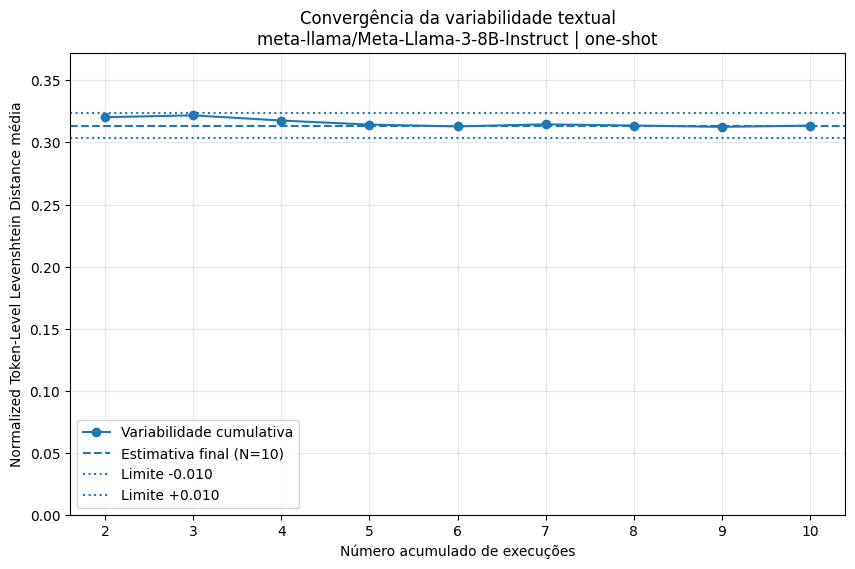

In [ ]:

# =========================
# GRÁFICO DA CONVERGÊNCIA
# =========================

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    curva[
        "n_execucoes"
    ],
    curva[
        "media_variabilidade_levenshtein"
    ],
    marker="o",
    label="Variabilidade cumulativa"
)

plt.axhline(
    V_FINAL,
    linestyle="--",
    label=f"Estimativa final (N={N_MAX})"
)

limite_inf = max(
    0.0,
    V_FINAL
    - TOLERANCIA_ABSOLUTA
)

limite_sup = min(
    1.0,
    V_FINAL
    + TOLERANCIA_ABSOLUTA
)

plt.axhline(
    limite_inf,
    linestyle=":",
    label=(
        f"Limite -"
        f"{TOLERANCIA_ABSOLUTA:.3f}"
    )
)

plt.axhline(
    limite_sup,
    linestyle=":",
    label=(
        f"Limite +"
        f"{TOLERANCIA_ABSOLUTA:.3f}"
    )
)

if PONTO_CONVERGENCIA is not None:

    plt.axvline(
        PONTO_CONVERGENCIA,
        linestyle="--",
        label=(
            f"Convergência: "
            f"N={PONTO_CONVERGENCIA}"
        )
    )

plt.xlabel(
    "Número acumulado de execuções"
)

plt.ylabel(
    "Normalized Token-Level "
    "Levenshtein Distance média"
)

plt.title(
    f"Convergência da variabilidade textual\n"
    f"{modelo_llm} | {tecnica}"
)

plt.ylim(
    0,
    min(
        1.0,
        max(
            curva[
                "media_variabilidade_levenshtein"
            ].max()
            + 0.05,
            limite_sup
            + 0.02
        )
    )
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.show()


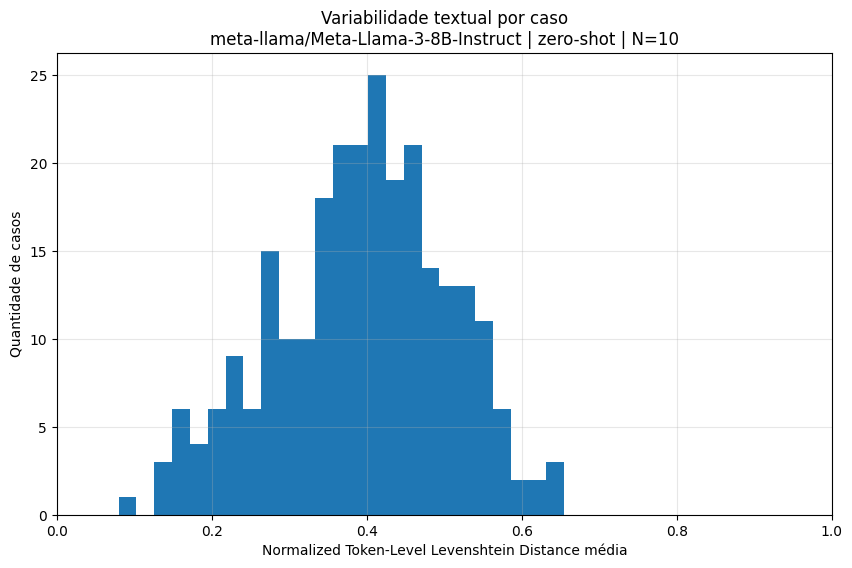

In [ ]:

# =========================
# DISTRIBUIÇÃO DA VARIABILIDADE FINAL
# =========================

plt.figure(
    figsize=(10, 6)
)

plt.hist(
    variabilidade_casos[
        "levenshtein_tokens_norm_media"
    ],
    bins=25
)

plt.xlabel(
    "Normalized Token-Level "
    "Levenshtein Distance média"
)

plt.ylabel(
    "Quantidade de casos"
)

plt.title(
    f"Variabilidade textual por caso\n"
    f"{modelo_llm} | {tecnica} | N={N_MAX}"
)

plt.xlim(
    0,
    1
)

plt.grid(
    alpha=0.3
)

plt.show()


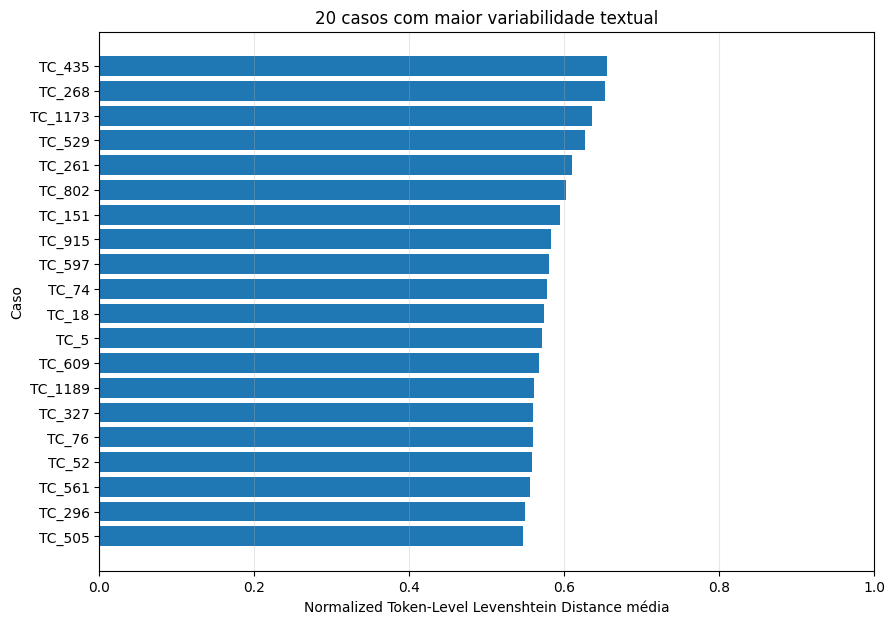

In [ ]:

# =========================
# CASOS MAIS VARIÁVEIS
# =========================

top = (
    variabilidade_casos
    .head(
        TOP_CASOS
    )
    .sort_values(
        "levenshtein_tokens_norm_media",
        ascending=True
    )
)

plt.figure(
    figsize=(
        10,
        max(
            6,
            TOP_CASOS * 0.35
        )
    )
)

plt.barh(
    top[
        "case_id"
    ],
    top[
        "levenshtein_tokens_norm_media"
    ]
)

plt.xlabel(
    "Normalized Token-Level "
    "Levenshtein Distance média"
)

plt.ylabel(
    "Caso"
)

plt.title(
    f"{TOP_CASOS} casos "
    "com maior variabilidade textual"
)

plt.xlim(
    0,
    1
)

plt.grid(
    axis="x",
    alpha=0.3
)

plt.show()


In [ ]:

# =========================
# SALVAMENTO
# =========================

def slug(texto):
    texto = str(
        texto
    ).lower()

    texto = re.sub(
        r"[^a-z0-9]+",
        "-",
        texto
    )

    return (
        texto
        .strip("-")[:80]
    )


base_saida = (
    f"{slug(modelo_llm)}_"
    f"{slug(tecnica)}"
)

arquivo_curva = (
    "convergencia_levenshtein_tokens_"
    f"{base_saida}.csv"
)

arquivo_casos = (
    "variabilidade_levenshtein_tokens_por_caso_"
    f"{base_saida}.csv"
)

arquivo_json = (
    "resumo_variabilidade_levenshtein_tokens_"
    f"{base_saida}.json"
)

curva.to_csv(
    arquivo_curva,
    index=False,
    encoding="utf-8-sig"
)

variabilidade_casos.to_csv(
    arquivo_casos,
    index=False,
    encoding="utf-8-sig"
)

saida_json = {
    "summary":
        resumo_global,

    "sensitivity_analysis":
        sensibilidade.to_dict(
            orient="records"
        ),

    "convergence_curve":
        curva.to_dict(
            orient="records"
        ),

    "case_variability":
        variabilidade_casos.to_dict(
            orient="records"
        )
}

with open(
    arquivo_json,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        saida_json,
        f,
        ensure_ascii=False,
        indent=2
    )

print(
    "Arquivos gerados:"
)

print(
    "-",
    arquivo_curva
)

print(
    "-",
    arquivo_casos
)

print(
    "-",
    arquivo_json
)

# No Colab, se quiser baixar:
#
# from google.colab import files
# files.download(arquivo_curva)
# files.download(arquivo_casos)
# files.download(arquivo_json)


Arquivos gerados:
- convergencia_levenshtein_tokens_meta-llama-meta-llama-3-8b-instruct_zero-shot.csv
- variabilidade_levenshtein_tokens_por_caso_meta-llama-meta-llama-3-8b-instruct_zero-shot.csv
- resumo_variabilidade_levenshtein_tokens_meta-llama-meta-llama-3-8b-instruct_zero-shot.json



# Interpretação

## 1. Variabilidade textual

O principal indicador por caso é:

`levenshtein_tokens_norm_media`

Ele está em \([0,1]\):

- mais próximo de `0` → gerações textualmente mais estáveis;
- maior → gerações textualmente mais diferentes.

Exemplo:

`0.18`

significa uma **distância de edição normalizada média de 0,18** entre as gerações daquele caso.

Evite escrever simplesmente “18% semanticamente diferentes”. A métrica não mede semântica.

## 2. O que conta como diferença

Por padrão:

- `Given` vs `When` conta como substituição;
- uma palavra adicional conta como inserção;
- uma palavra ausente conta como remoção;
- sinônimos diferentes contam como tokens diferentes;
- diferenças apenas de maiúsculas/minúsculas são ignoradas;
- espaços/indentação não contam;
- pontuação conta, porque `CONSIDERAR_PONTUACAO = True`.

## 3. Comparação dos 5 modelos × 3 técnicas

Execute o mesmo notebook para os 15 JSONs.

O indicador global principal é:

`global_mean_case_variability`

Como todos usam a mesma métrica em escala \([0,1]\), os valores podem ser comparados diretamente entre as configurações experimentais.

Reporte também:

- `global_median_case_variability`;
- `global_sd_between_cases`;
- `global_iqr_between_cases`;
- IC bootstrap de 95% da média global.

## 4. Convergência

`convergence_point` é o menor número de execuções a partir do qual:

1. a estimativa permaneceu dentro da tolerância absoluta em relação a \(V(N)\);
2. nunca mais saiu dessa faixa até a última execução;
3. existiram execuções posteriores suficientes para confirmar a estabilidade.

Exemplo:

- `reference_n = 20`;
- `convergence_point = 11`;
- `absolute_tolerance = 0.01`;
- `minimum_posterior_executions = 5`.

Interpretação:

> A partir de 11 execuções, a estimativa cumulativa da variabilidade textual permaneceu a no máximo 0,01 unidade da estimativa obtida com 20 execuções, mantendo esse comportamento nas execuções posteriores observadas.

## 5. Um único número de repetições para o estudo

Depois de executar os 15 arquivos:

\[
N_{final}
=
\max(
N_{\text{convergência das 15 configurações}}
)
\]

Se alguma configuração não apresentar convergência confirmada no horizonte disponível, aumente o número de execuções dessa análise antes de definir \(N_{final}\).

## 6. Sensibilidade da tolerância

A tabela `sensibilidade` mostra o ponto de convergência para diferentes tolerâncias, por padrão:

- 0,005;
- 0,010;
- 0,020.

Isso ajuda a demonstrar quanto a conclusão sobre o número de execuções depende do critério de precisão adotado.
